Import Libraries

In [20]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# Import Dataset & Extract Features/Target

In [21]:
real_data = pd.read_csv('../data/scamaap dataset.csv').drop(columns=['NtsbNo', 'Event.Date'])
real_data = real_data.rename(columns={'merged_air_crash_data_weather.sky_cond_nonceil': 'SkyCondNonceil'})
target_names = ['Supervisory Conditions', 'Operator Conditions', 'Unsafe Conditions']
y_data = real_data[target_names]
X_data = real_data.drop(columns=target_names)
feature_names = X_data.columns

## Separate Numerical & Categorical Data (ML Features Only)

In [22]:
# Only include features that are actually used in the ML pipeline
ml_num_features = ['Employment, Total Weighted Avg CY_QoQ_pct']
ml_cat_features = [
    'Organizational Climate',
    'WeatherCondition',
    'TimeOfDay',
    'SkyCondNonceil',
    'Personnel Conditions'
]

num_features = ml_num_features
cat_features = ml_cat_features

num_data = real_data[ml_num_features + target_names]
cat_data = real_data[ml_cat_features + target_names]

# Missing Value Analysis

Missing Values Summary:
                           Missing Count  Missing %
SkyCondNonceil                       917      75.23
WeatherCondition                      43       3.53
Operating Expense per RTM             33       2.71
Personnel Conditions                   7       0.57
Supervisory Conditions                 6       0.49


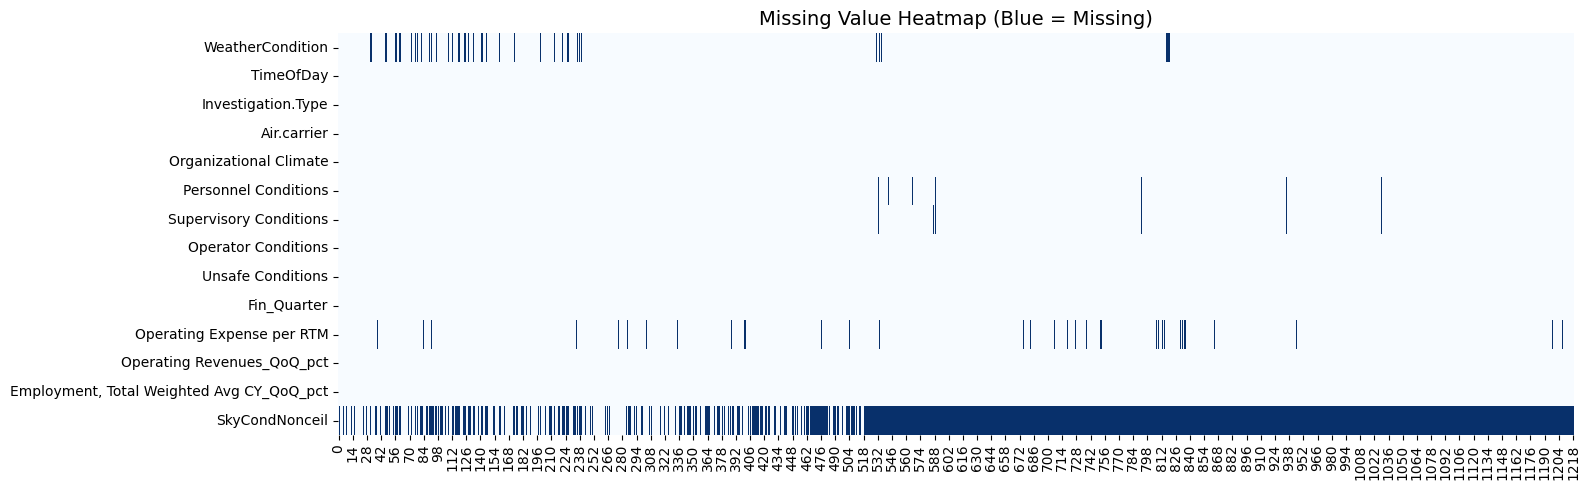

In [23]:
# Missing value counts and percentages
missing_count = real_data.isnull().sum()
missing_pct = (missing_count / len(real_data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Missing Values Summary:')
print(missing_df.to_string())

# Missingness heatmap (blue = missing)
plt.figure(figsize=(16, 5))
sns.heatmap(
    real_data.isnull().T,
    cbar=False,
    cmap='Blues',
    yticklabels=real_data.columns
)
plt.title('Missing Value Heatmap (Blue = Missing)', fontsize=14)
plt.tight_layout()
plt.savefig('missing_value_heatmap.png')
plt.show()

# Plot Feature Distribution Graphs

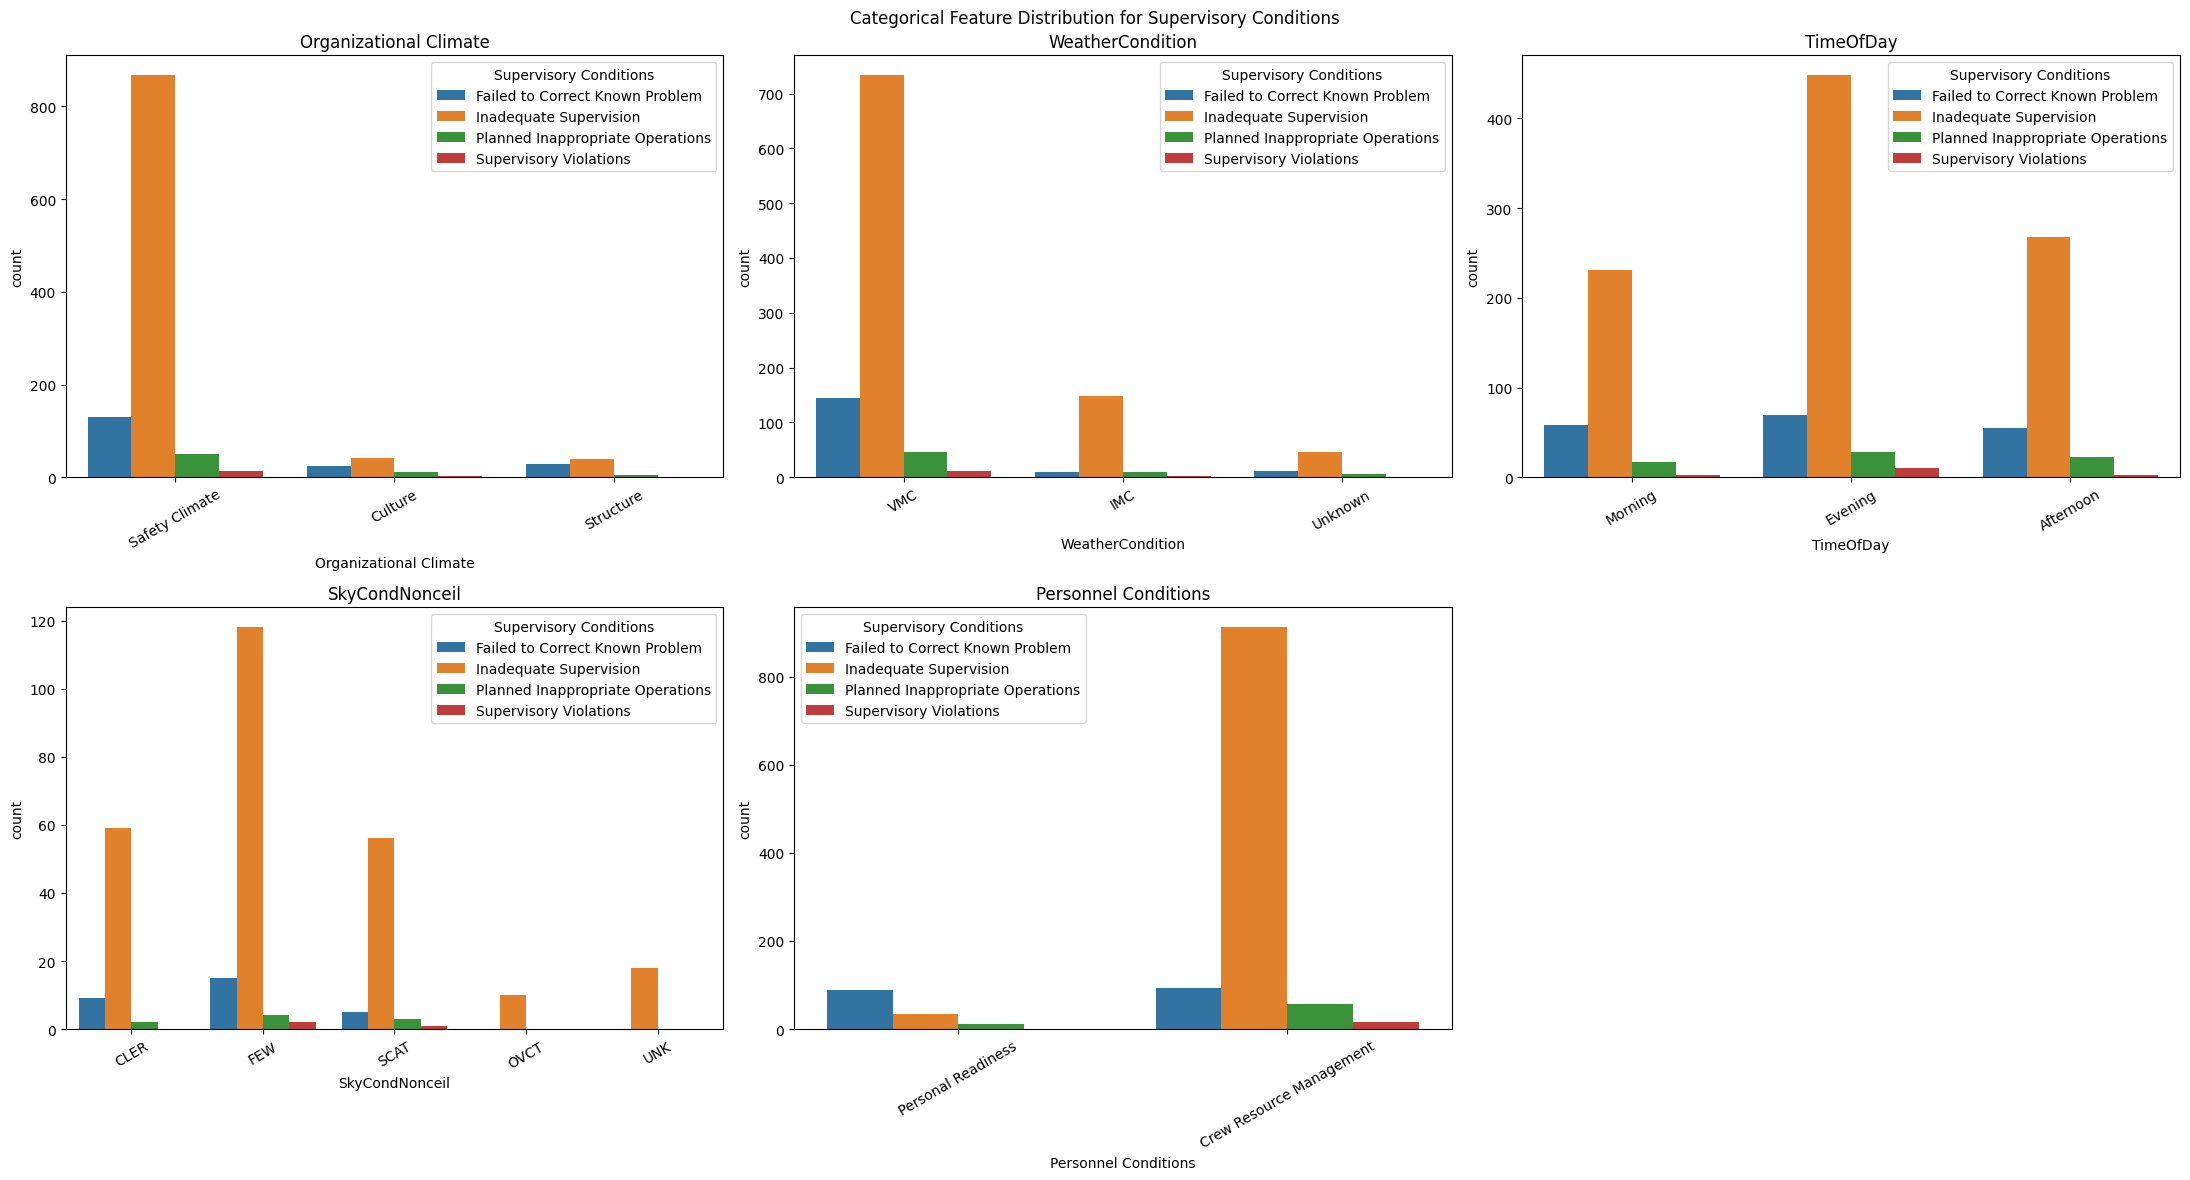

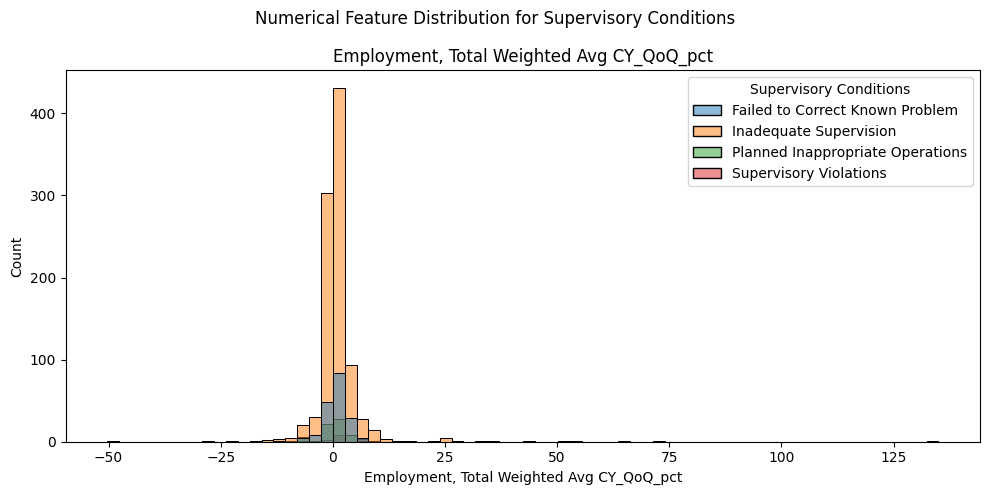

KeyboardInterrupt: 

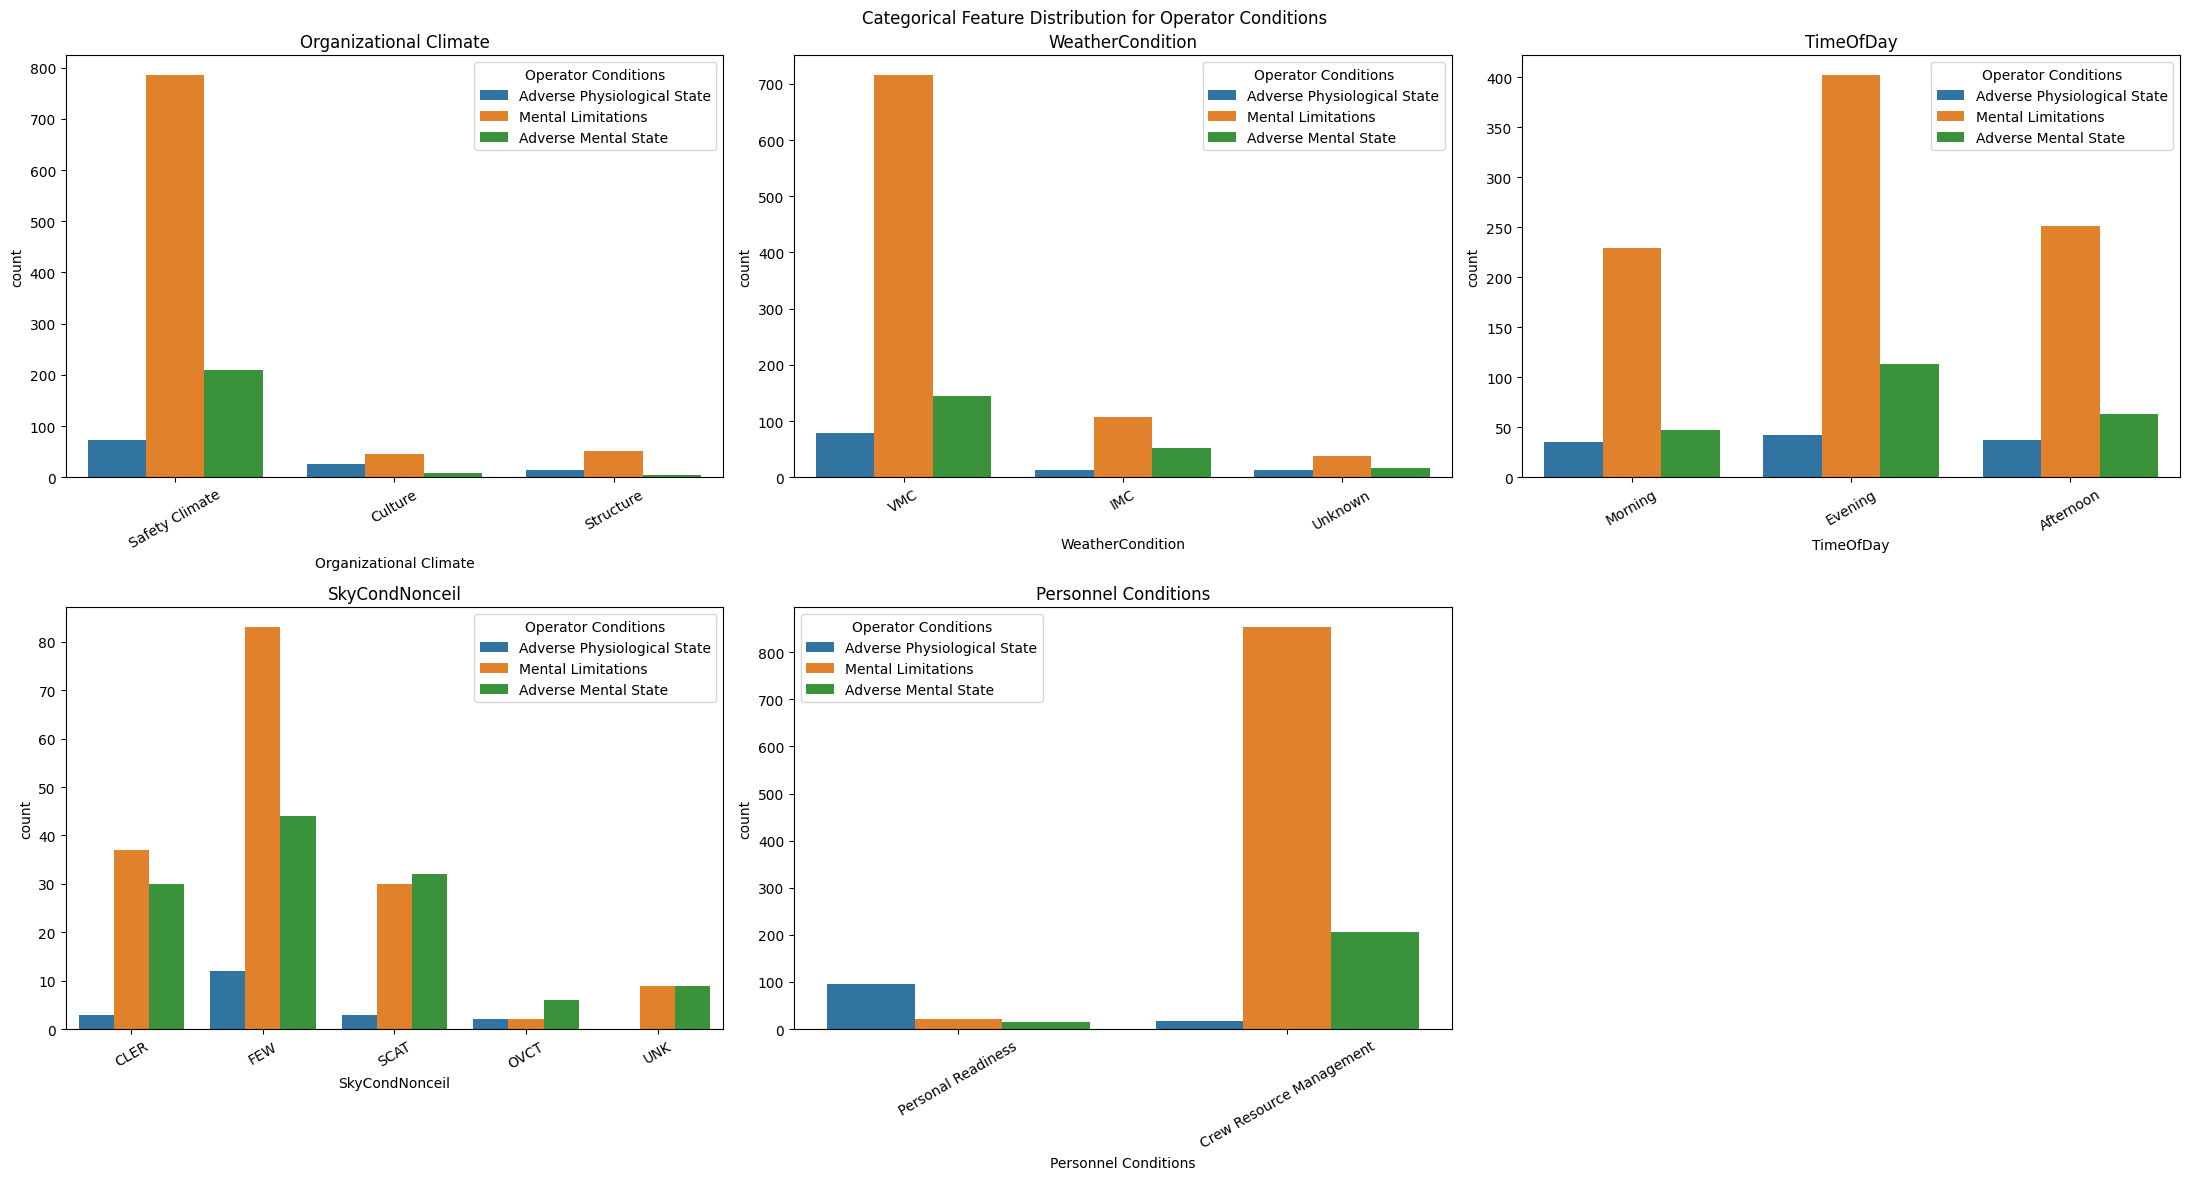

In [24]:
for class_name in target_names:
    rem_names = [name for name in target_names if name != class_name]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))
    axes = axes.flatten()
    for ax, col in zip(axes, cat_features):
        sns.countplot(data=cat_data.drop(rem_names, axis=1), x=col, hue=class_name, ax=ax)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=30)
    # Hide any unused axes
    for ax in axes[len(cat_features):]:
        ax.set_visible(False)
    fig.suptitle('Categorical Feature Distribution for ' + class_name)
    plt.tight_layout()
    plt.savefig('cat_feature_bar_' + class_name + '.png')
    plt.show()

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    sns.histplot(data=num_data.drop(rem_names, axis=1), x=num_features[0], hue=class_name, ax=axes)
    axes.set_title(num_features[0])
    fig.suptitle('Numerical Feature Distribution for ' + class_name)
    plt.tight_layout()
    plt.savefig('num_feature_bar_' + class_name + '.png')
    plt.show()

# Employment Distribution

In [ ]:
emp_col = 'Employment, Total Weighted Avg CY_QoQ_pct'
df_emp = real_data[[emp_col, 'Supervisory Conditions']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot with outlier markers
sns.boxplot(
    data=real_data,
    y=emp_col,
    ax=axes[0],
    color='steelblue',
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
axes[0].set_title('Employment QoQ % — Box Plot (with Outliers)', fontsize=12)
axes[0].set_ylabel('Employment QoQ %')

# Violin plot split by Supervisory Conditions
sns.violinplot(
    data=df_emp,
    x='Supervisory Conditions',
    y=emp_col,
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Employment QoQ % by Supervisory Conditions', fontsize=12)
axes[1].set_xlabel('Supervisory Conditions')
axes[1].set_ylabel('Employment QoQ %')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('employment_distribution.png')
plt.show()

print('Employment QoQ % Descriptive Statistics:')
print(real_data[emp_col].describe().round(2).to_string())
print(f'Skewness: {real_data[emp_col].skew():.3f}')

# Correlation Heatmap

In [ ]:
# Numerical features — Spearman correlation
# Encode targets numerically to measure monotonic association with Employment QoQ %
df_spearman = real_data[ml_num_features + target_names].dropna().copy()
for t in target_names:
    df_spearman[t] = LabelEncoder().fit_transform(df_spearman[t])

spearman_corr = df_spearman.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=1
)
plt.title('Numerical Feature Spearman Correlation\n(Employment QoQ % vs Targets)', fontsize=14)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig('spearman_corr_matrix.png')
plt.show()

In [ ]:
# Categorical features — Cramér's V association matrix
from dython.nominal import associations

cat_corr_cols = ml_cat_features + target_names
df_cat_corr = real_data[cat_corr_cols].copy().astype('object')
assoc_result = associations(df_cat_corr, nominal_columns=cat_corr_cols, compute_only=True)
assoc_matrix = assoc_result['corr']

plt.figure(figsize=(12, 8))
sns.heatmap(
    assoc_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=1
)
plt.title("Categorical Features — Cramér's V Association\n(ML Features + Targets)", fontsize=14)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig('cramersv_corr_matrix.png')
plt.show()

# Domain Insights

In [ ]:
# --- Top-20 Air Carriers, Financial Quarter, Investigation Type ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Top-20 air carriers by accident count
carrier_counts = real_data['Air.carrier'].value_counts().head(20)
sns.barplot(x=carrier_counts.values, y=carrier_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 20 Air Carriers by Accident Count', fontsize=12)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Air Carrier')

# Accident counts by financial quarter
quarter_counts = real_data['Fin_Quarter'].value_counts().sort_index()
sns.barplot(x=quarter_counts.index.astype(str), y=quarter_counts.values, ax=axes[1], palette='Set2')
axes[1].set_title('Accident Counts by Financial Quarter', fontsize=12)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Count')

# Investigation type distribution
inv_counts = real_data['Investigation.Type'].value_counts()
sns.barplot(x=inv_counts.index, y=inv_counts.values, ax=axes[2], palette='Set3')
axes[2].set_title('Investigation Type Distribution', fontsize=12)
axes[2].set_xlabel('Investigation Type')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('domain_insights_overview.png')
plt.show()

# Investigation type breakdown per target
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, target in zip(axes, target_names):
    ct = pd.crosstab(real_data['Investigation.Type'], real_data[target])
    ct.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(f'Investigation Type vs {target}', fontsize=11)
    ax.set_xlabel('Investigation Type')
    ax.set_ylabel('Count')
    ax.legend(title=target, bbox_to_anchor=(1, 1), fontsize=7)
plt.tight_layout()
plt.savefig('investigation_type_by_target.png')
plt.show()

# Pre/Post-SMOTE Class Balance

In [ ]:
# Replicate training split and SMOTE logic from data/real_dataloader.py
df_smote = real_data.copy()
df_smote['WeatherCondition']   = df_smote['WeatherCondition'].fillna('Unknown')
df_smote['SkyCondNonceil']     = df_smote['SkyCondNonceil'].fillna('Unknown')
df_smote['Personnel Conditions'] = df_smote['Personnel Conditions'].fillna('Unknown')
df_smote = df_smote.dropna(subset=target_names).reset_index(drop=True)

# 70% training split (fixed seed)
rng = np.random.RandomState(42)
idx = rng.permutation(len(df_smote))
n_train = int(len(df_smote) * 0.7)
df_train = df_smote.iloc[idx[:n_train]].reset_index(drop=True)

# Encode ML categorical features and targets on training split
enc = {}
for col in ml_cat_features:
    enc[col] = LabelEncoder().fit(df_train[col])
for t in target_names:
    enc[t] = LabelEncoder().fit(df_train[t])

# Feature matrix (step0 equivalent: categorical ML features)
X_train = np.column_stack([enc[c].transform(df_train[c]) for c in ml_cat_features])
y_trains = {t: enc[t].transform(df_train[t]) for t in target_names}

def safe_smote(X, y, seed=42):
    counts = np.bincount(y)
    min_count = counts[counts > 0].min()
    if min_count < 2:
        return y
    k = min(5, min_count - 1)
    sm = SMOTETomek(smote=SMOTE(random_state=seed, k_neighbors=k), random_state=seed)
    _, y_res = sm.fit_resample(X, y)
    return y_res

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
for col_idx, target in enumerate(target_names):
    y_before = y_trains[target]
    y_after  = safe_smote(X_train, y_before)
    classes  = enc[target].classes_
    n_cls    = len(classes)

    before_counts = [np.sum(y_before == i) for i in range(n_cls)]
    after_counts  = [np.sum(y_after  == i) for i in range(n_cls)]

    axes[0, col_idx].bar(range(n_cls), before_counts, color='steelblue', edgecolor='black')
    axes[0, col_idx].set_xticks(range(n_cls))
    axes[0, col_idx].set_xticklabels(classes, rotation=30, ha='right', fontsize=8)
    axes[0, col_idx].set_title(f'{target}\nBefore SMOTE', fontsize=11)
    axes[0, col_idx].set_ylabel('Count')

    axes[1, col_idx].bar(range(n_cls), after_counts, color='darkorange', edgecolor='black')
    axes[1, col_idx].set_xticks(range(n_cls))
    axes[1, col_idx].set_xticklabels(classes, rotation=30, ha='right', fontsize=8)
    axes[1, col_idx].set_title(f'{target}\nAfter SMOTETomek', fontsize=11)
    axes[1, col_idx].set_ylabel('Count')

    bc = np.array(before_counts)
    ac = np.array(after_counts)
    print(f'\n{target}')
    print(f'  Before — imbalance ratio: {bc.max()/bc.min():.1f}:1')
    print(f'  After  — imbalance ratio: {ac.max()/ac.min():.1f}:1')

fig.suptitle('Class Distribution Before vs. After SMOTETomek (Training Split Only)', fontsize=14)
plt.tight_layout()
plt.savefig('smote_comparison.png')
plt.show()

# SHAP

## LSTM SHAP

## Bayesian SHAP

## RF SHAP

In [ ]:
from sys import path
path.insert(0,'..')

In [ ]:
from models.random_forest.train import trainPipeline
import shap

c:\Users\Isaac Morrison\OneDrive\Documents\GitHub\Sequential-Causal-Architecture-for-Multimodal-Aviation-Accident-Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# RANDOM FOREST (Ensemble)
rf_model_1, rf_model_2, rf_model_3, datasplit = trainPipeline()
rf_train, rf_val, rf_test = datasplit


Train: 850  Val: 121  Test: 242
Training rows after SMOTE: 4763
Models saved to c:\Users\Isaac Morrison\OneDrive\Documents\GitHub\Sequential-Causal-Architecture-for-Multimodal-Aviation-Accident-Prediction\notebooks\..\models\random_forest\hfacs_rf.pkl

Metric                  A (Supervisory)   B (Operator)  C (Unsafe Acts)
------------------------------------------------------------------------
Balanced Accuracy                40.88%         61.45%           31.13%
Macro F1                         0.4128         0.6347           0.2854
Cohen Kappa                      0.2110         0.4614           0.1011


In [36]:
from models.random_forest.train import FEAT_COLS_1, FEAT_COLS_2, FEAT_COLS_3

input_1 = rf_test[FEAT_COLS_1]

A_test = rf_test['Supervisory Conditions']
B_test = rf_test['Operator Conditions']
C_test = rf_test['Unsafe Conditions']

#rf_test

In [53]:
def VisualizeSHAP(shap_values, input):
    # Visualization : Waterfall Plot (local)
    sample_idx = 0
    fig1 = plt.figure()
    shap.plots.waterfall(shap_values[sample_idx,:,1], show=False)
    plt.title(f"Decision Tree: Explanation for Patient: {sample_idx}")
    plt.show()

    fig2 = plt.figure(figsize=(5,5))
    shap.summary_plot(shap_values[:,:,1], input, show=False)
    plt.title(f"Decision Tree: Global Feature Importance")
    plt.show()

 96%|=================== | 929/968 [00:18<00:00]       

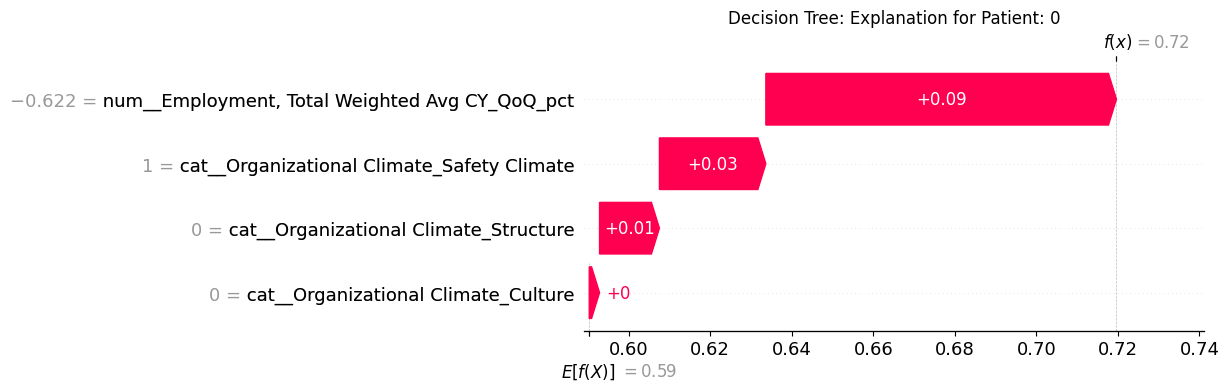

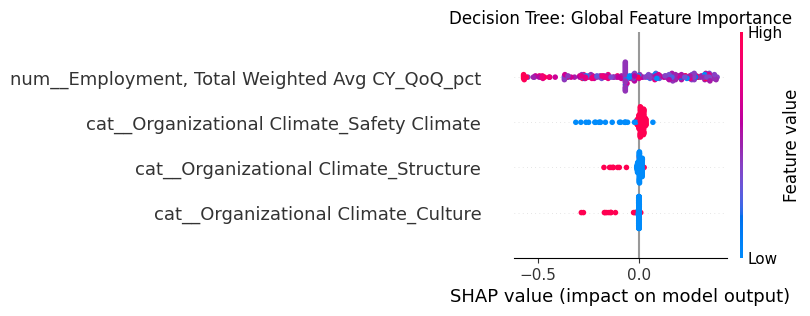

In [54]:
encoder_1 = rf_model_1.named_steps['encoder']
feature_names_1 = encoder_1.get_feature_names_out()
rf_model_1_extracted = rf_model_1.named_steps['rf']

test_1_prep = encoder_1.transform(input_1)
explainer_rf_1 = shap.TreeExplainer(rf_model_1_extracted, test_1_prep, feature_names=feature_names_1)
shap_values_rf_1 = explainer_rf_1(test_1_prep)

VisualizeSHAP(shap_values=shap_values_rf_1, input=test_1_prep)


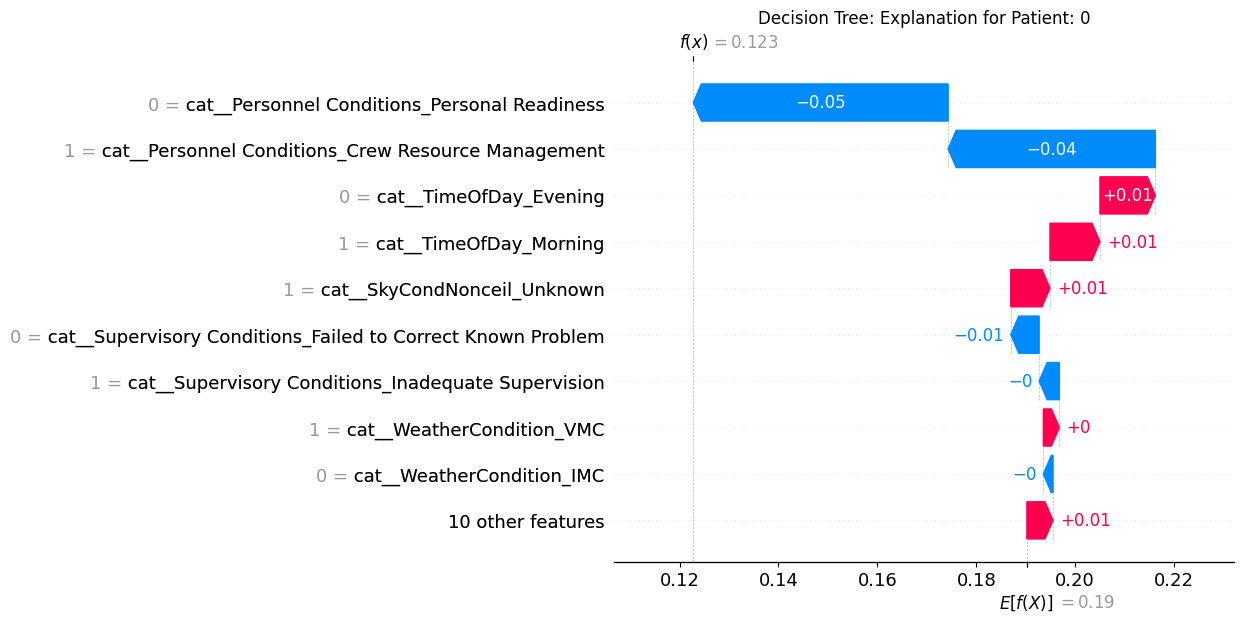

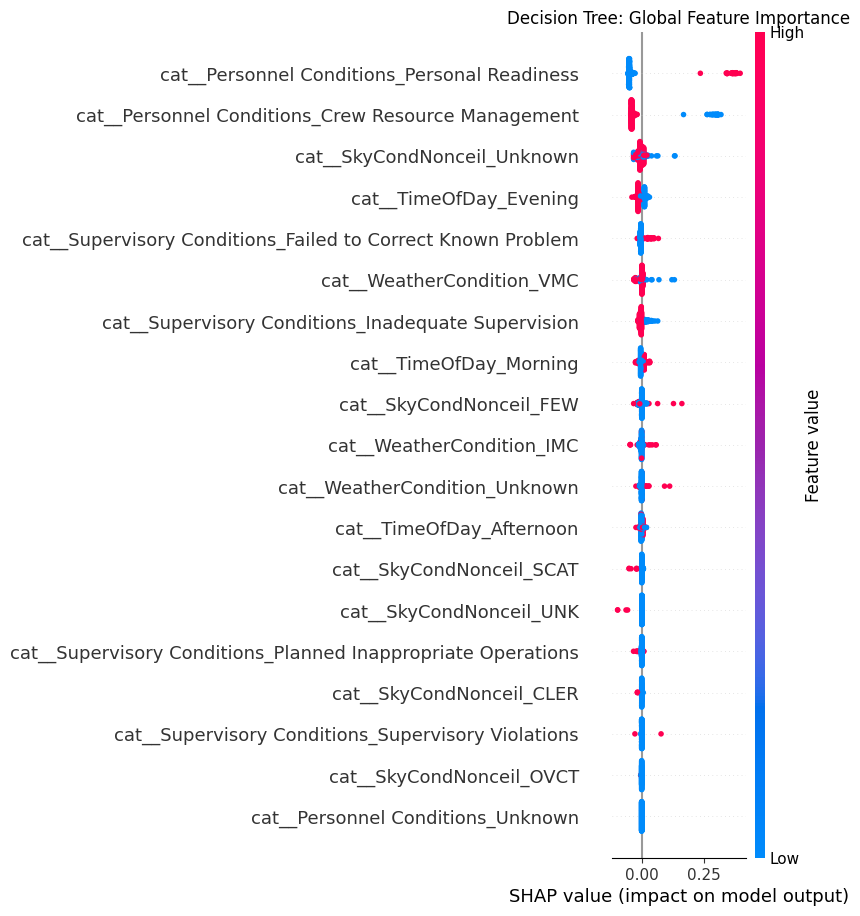

In [78]:
input_2 = rf_test[FEAT_COLS_2].copy()
input_2["Supervisory Conditions"] = A_test

encoder_2 = rf_model_2.named_steps['encoder']
feature_names_2 = encoder_2.get_feature_names_out()
rf_model_2_extracted = rf_model_2.named_steps['rf']
test_2_prep = encoder_2.transform(input_2).toarray()

explainer_rf_2 = shap.TreeExplainer(rf_model_2_extracted, data=test_2_prep, feature_names=feature_names_2)
shap_values_rf_2 = explainer_rf_2(test_2_prep)

VisualizeSHAP(shap_values=shap_values_rf_2, input=test_2_prep)

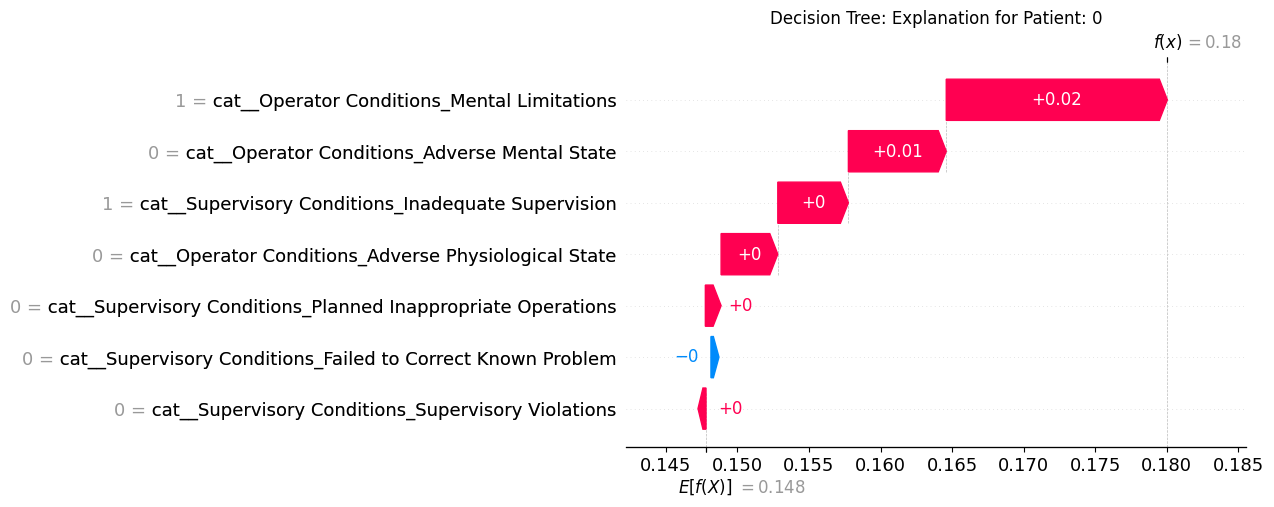

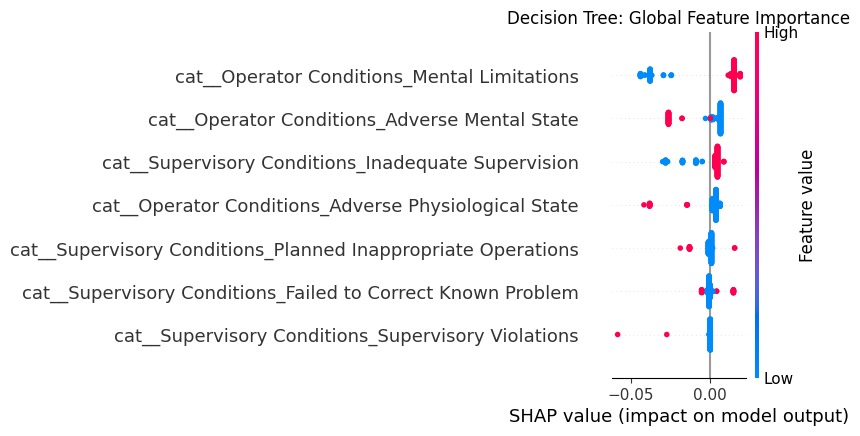

In [ ]:
input_3 = pd.DataFrame({
    "Supervisory Conditions": A_test,
    "Operator Conditions":    B_test,
})

encoder_3 = rf_model_3.named_steps['encoder']
feature_names_3 = encoder_3.get_feature_names_out()
rf_model_3_extracted = rf_model_3.named_steps['rf']
test_3_prep = encoder_3.transform(input_3).toarray()

explainer_rf_3 = shap.TreeExplainer(rf_model_3_extracted, data=test_3_prep, feature_names=feature_names_3)
shap_values_rf_3 = explainer_rf_3(test_3_prep)

VisualizeSHAP(shap_values=shap_values_rf_3, input=test_3_prep)